# OPTİMİZASYON

# İkiye Bölme Yöntemi

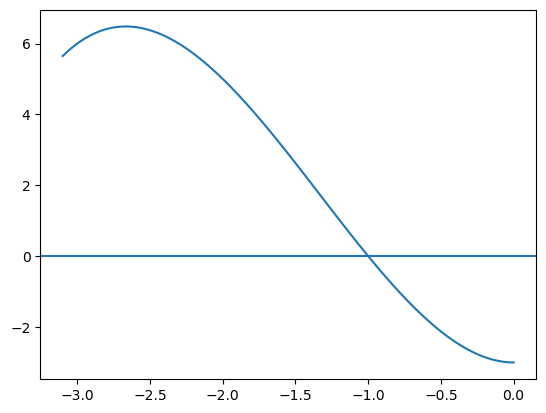

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**3 + 4 * x**2 - 3

x = np.linspace(-3.1, 0, 100)
plt.plot(x, f(x))

xaxis = plt.axhline(0)

In [12]:
sol = -3    #f(sol) > 0
sag = -0.5  #f(sag) < 0

hata = 10 ** -10



sayac = 0

while sag - sol > hata:
    
  orta = 0.5 * (sol + sag)

  if f(orta) > 0:
    sol = orta
  elif f(orta) < 0:
    sag = orta
  else:
    sol = orta
    sag = orta
    
  sayac += 1

print(sol, f(sol), sayac)

-1.0000000000291038 1.4551915228366852e-10 35


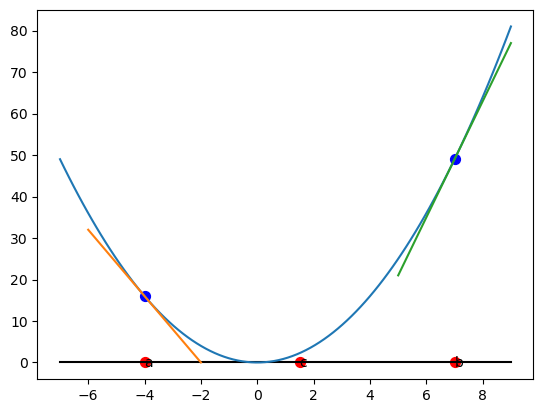

In [15]:
def g(x):
  return x ** 2

def g_turev(x):
  return 2 * x

sol = -4    #g_turev(sol) < 0
sag = 7     #g_turev(sag) > 0
orta = 0.5 * (sol + sag)

plt.text(sol,-1,"a")
plt.text(sag,-1,"b")
plt.text(orta,-1,"c")

x = np.linspace(-7, 9, 100)
plt.plot(x, 0 * x, color='black')
plt.scatter([sol, orta, sag], [0, 0, 0], s=50, color='red')
plt.scatter([sol, sag], [g(sol),g(sag)], s=50, color='blue')



x = np.linspace(-7, 9, 100)
plt.plot(x, g(x))


x = np.linspace(sol - 2, sol + 2, 30)
plt.plot(x, 2 * sol * x + (sol ** 2 - 2 * sol * sol))

x = np.linspace(sag - 2, sag + 2, 30)
plt.plot(x, 2 * sag * x + (sag ** 2 - 2 * sag * sag))

In [16]:
def g(x):
  return x ** 2 + 1

def g_turev(x):
  return 2 * x

sol = -4    #g_turev(sol) < 0
sag = 7     #g_turev(sag) > 0


hata = 10 ** -10


sayac = 0

while sag - sol > hata:
    
  orta = 0.5 * (sol + sag)

  if g_turev(orta) < 0:
    sol = orta
  elif g_turev(orta) > 0:
    sag = orta
  else:
    sol = orta
    sag = orta

  sayac += 1

print(sol, g_turev(sol), g(sol), sayac)


-4.3655745685100555e-11 -8.731149137020111e-11 1.0 37


In [18]:
def g(x):
  return x ** 2 - 6 * x + 5  #(x-1)(x-5)

def g_turev(x):
  return 2 * x - 6  

sol = -4    #g_turev(sol) < 0
sag = 7     #g_turev(sag) > 0


hata = 10 ** -10


orta = 0.5 * (sol + sag)
sayac = 0

while sag - sol > hata:

  if g_turev(orta) < 0:
    sol = orta
  elif g_turev(orta) > 0:
    sag = orta
  else:
    sol = orta
    sag = orta

  orta = 0.5 * (sol + sag)
  sayac += 1

print(orta, g_turev(orta), g(orta), sayac)

3.000000000003638 7.275957614183426e-12 -4.0 37


In [19]:
def g(x):
  return x ** 2 - 6 * x  + 5  #(x-1)(x-5)
  

# Girdisi fonksiyon olan bir fonksiyon. 
# Verilen fonsiyonun x noktasindaki turevini numerik hesaplayan bir fonksiyon
def turev(g, x):  
  h = 10 ** -10
  return (g(x + h) - g(x - h)) / (2 * h) ## Sagdan ve soldan turevlerin ortalamalari 
  #return (g(x+h) - g(x)) / h # Sagdan türev


sol = -4    #g_turev(sol) < 0
sag = 7     #g_turev(sag) > 0


hata = 10 ** -10


orta = 0.5 * (sol + sag)
sayac = 0

while sag - sol > hata:

  if turev(g, orta) < 0:
    sol = orta
  elif turev(g, orta) > 0:
    sag = orta
  else:
    sol = orta
    sag = orta

  orta = 0.5 * (sol + sag)
  sayac += 1

print(orta, turev(g, orta), g(orta), sayac)

3.0000038146972656 0.0 -3.999999999985448 18


# Grandyan iniş algoritması 

In [46]:
def g(x):
  return x ** 2 - 6 * x + 5  #(x-1)(x-5)

def g_turev(x):
  return 2 * x - 6

# Algoritmanin ogrenme hizi
c = 0.1
# Baslangic degeri
x = 1410

# Maksimum turev hatasi
hata = 10 ** -10

# Adim sayaci
sayac = 0

while abs(g_turev(x)) > hata:
  x = x - c * g_turev(x) 
  sayac += 1
  if sayac > 1500000:
    print("Maksimum iterasyon sayisina erisildi!")
    break


print(x, g_turev(x), g(x), sayac)

3.0000000000476215 9.524292465812323e-11 -4.000000000000002 139


# Çok Değişkenli Gradyan İniş

In [47]:
# Vektor normu hesaplayan fonksiyon

def norm(x):

  toplam = 0

  for i in range(len(x)):
    toplam += x[i] ** 2
  
  return np.sqrt(toplam)

g(x,y) = (x - 2)^2 + (y + 1)^2 dışbükey fonksiyonunun minimum noktasını bulalım.

In [48]:
# Fonksiyon ve gradyan tanimi

def g(a,b):
  return (a - 2) ** 2 + (b + 1) ** 2

def grad_g(a,b):
  return np.array([2 * (a - 2), 2 * (b + 1)])

In [64]:
nokta = np.array([10, -30])

c = 0.1

hata = 10 ** -10

gradyan = grad_g(nokta[0], nokta[1])

sayac = 1

while norm(gradyan) > hata:

  nokta = nokta - c * gradyan

  if sayac % 10 == 0:
    print(sayac, nokta, gradyan)

  gradyan = grad_g(nokta[0], nokta[1])

  sayac += 1

  if sayac > 500000:
    print("Maksimum iterasyon sayisina erisildi!")
    break

print(sayac, nokta, gradyan)

10 [ 2.85899346 -4.11385129] [ 2.14748365 -7.78462822]
20 [ 2.09223372 -1.33434724] [ 0.2305843  -0.83586809]
30 [ 2.00990352 -1.03590026] [ 0.0247588  -0.08975065]
40 [ 2.00106338 -1.00385476] [ 0.00265846 -0.0096369 ]
50 [ 2.00011418 -1.0004139 ] [ 0.00028545 -0.00103475]
60 [ 2.00001226 -1.00004444] [ 3.06499108e-05 -1.11105927e-04]
70 [ 2.00000132 -1.00000477] [ 3.29100912e-06 -1.19299080e-05]
80 [ 2.00000014 -1.00000051] [ 3.53369414e-07 -1.28096412e-06]
90 [ 2.00000002 -1.00000006] [ 3.79427521e-08 -1.37542475e-07]
100 [ 2.         -1.00000001] [ 4.07407175e-09 -1.47685109e-08]
110 [ 2. -1.] [ 4.37450076e-10 -1.58575686e-09]
120 [ 2. -1.] [ 4.69713157e-11 -1.70269576e-10]
123 [ 2. -1.] [ 2.40492071e-11 -8.71778205e-11]


## Şimdi uygulama olarak dogrusal baglanımdaki Kalıntı Kareler Toplamını (KKT) minimize edelim:

In [65]:
import pandas as pd

veri = pd.read_csv("/Users/ozgur/Library/CloudStorage/GoogleDrive-ozgurmartin@gmail.com/My Drive/Academic/1. Okul Isleri/8) Galatasaray/Machine Learning/Course_materials/Course_Data/Advertising.csv")

veri.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


Karşılaştırmak için ilk önce sklearn kütüphanesi ile analitik çözümü yazdıralım:

In [66]:
from sklearn.linear_model import LinearRegression

x = np.array(veri['TV']).reshape(-1, 1)
y = np.array(veri['Sales'])

regr = LinearRegression()

regr.fit(x, y)

print('satış =', regr.intercept_, ' + ', regr.coef_[0], '* TV')

satış = 7.0325935491276965  +  0.047536640433019736 * TV


Şimdi KKT fonksiyonunu ve radyanını tanımlayalım.

In [67]:
x = np.array(veri['TV'])
y = np.array(veri['Sales'])


# f'nin radyanini hesaplamak icin gerekli degerler 
# (tekrar tekrar hesaplamamak icin onden yapiyoruz)

x_toplam = x.sum()
y_toplam = y.sum()
xy_toplam = (x * y).sum()
xx_toplam = (x * x).sum()

n = len(x)

# f fonksiyonu (veriye bagli)

def f(b0, b1):

  toplam = 0

  for i in range(len(x)):
    toplam += (y[i] - b0 - b1 * x[i]) ** 2

  return toplam / n

# f'nin gradyani. Veri sayısına bağlı olarak çok büyük sayılardan 
# kurtulmak için çıktıyı veri (satır) sayısına bölüyoruz

def grad_f(b0, b1):

  t1 = -2 * (y_toplam - n * b0 - x_toplam * b1) / n
  t2 = -2 * (xy_toplam - x_toplam * b0 - xx_toplam * b1) / n
  
  return np.array([t1, t2])


Gradyan iniş yöntemi ile optimizasyon:

In [76]:
nokta = np.array([10, 10])

c = 10**-5

hata = 10 ** -3

gradyan = grad_f(nokta[0], nokta[1])

sayac = 0


while norm(gradyan) > hata:

  nokta = nokta - c * gradyan

  if sayac % 100000 == 0:
    print(sayac, nokta, gradyan)

  gradyan = grad_f(nokta[0], nokta[1])

  sayac += 1

  if sayac > 1500000:
    print("Maksimum iterasyon sayisina erisildi!")
    break

print("Adım sayısı: ", sayac, "SONUÇ: Parametreler:", nokta, "Gradyanın son değeri: ", gradyan)

0 [9.97067195 4.22768394] [  2932.805  577231.6056]
100000 [8.79013347 0.03861141] [ 0.89030802 -0.00452121]
200000 [8.09162149 0.04215863] [ 0.53646638 -0.00272431]
300000 [7.67072425 0.04429605] [ 0.32325461 -0.00164157]
400000 [7.41710728 0.04558398] [ 0.19478116 -0.00098915]
500000 [7.26428717 0.04636004] [ 0.11736785 -0.00059602]
600000 [7.17220348 0.04682767] [ 0.07072149 -0.00035914]
700000 [7.11671728 0.04710944] [ 0.04261413 -0.00021641]
800000 [7.08328337 0.04727922] [ 0.02567768 -0.0001304 ]
900000 [7.06313734 0.04738153] [ 1.54724128e-02 -7.85728073e-05]
1000000 [7.0509981  0.04744318] [ 9.32309830e-03 -4.73450404e-05]
1100000 [7.04368344 0.04748032] [ 5.61775096e-03 -2.85283534e-05]
1200000 [7.03927591 0.04750271] [ 3.38504700e-03 -1.71901204e-05]
1300000 [7.03662009 0.04751619] [ 2.03970294e-03 -1.03581254e-05]
1400000 [7.03501979 0.04752432] [ 1.22904884e-03 -6.24141889e-06]
Adım sayısı:  1440717 SONUÇ: Parametreler: [7.03456761 0.04752662] Gradyanın son değeri:  [ 9.999

#### 

Sonuca ulaşmak çok uzun sürüyor. Nedeni verideki değerlerin ve dolayısı ile gradyanın çok büyük olması. Verinin girdisini normalize edelim:

In [77]:
max_tv = veri['TV'].abs().max() # TV sutununun mutlak degerlerinin maksimum degeri
veri['TV'] = veri['TV'] / max_tv

veri.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,0.776316,37.8,69.2,22.1
1,2,0.150135,39.3,45.1,10.4
2,3,0.058030,45.9,69.3,9.3
3,4,0.511134,41.3,58.5,18.5
4,5,0.609987,10.8,58.4,12.9


Karşılaştırma için değerleri sklearn kütüphanesine hesaplatalım. **TV'nin katsayısındaki normalizasyonu geri almayı unutmayın!**

In [78]:
x = np.array(veri['TV']).reshape(-1, 1)
y = np.array(veri['Sales'])

regr = LinearRegression()

regr.fit(x, y)


# TV'nin katsayısındaki normalizasyonu geri almayı unutmayın!
print('satış =', regr.intercept_, ' + ', regr.coef_[0] / max_tv, '* TV')

satış = 7.032593549127699  +  0.047536640433019715 * TV


Tekrar fonksiyonu ve gradyanı hesaplatalım (tanımlayalım):

In [79]:
x = np.array(veri['TV'])
y = np.array(veri['Sales'])


# f'nin radyanini hesaplamak icin gerekli degerler 
# (tekrar tekrar hesaplamamak icin onden yapiyoruz)

x_toplam = x.sum()
y_toplam = y.sum()
xy_toplam = (x * y).sum()
xx_toplam = (x * x).sum()

n = len(x)


# f fonksiyonu (veriye bagli)

def f(b0, b1):

  toplam = 0

  for i in range(len(x)):
    toplam += (y[i] - b0 - b1 * x[i]) ** 2

  return toplam / n

# f'nin gradyani. Veri sayısına bağlı olarak çok büyük sayılardan 
# kurtulmak için çıktıyı veri (satır) sayısına bölüyoruz

def grad_f(b0, b1):

  t1 = -2 * (y_toplam - n * b0 - x_toplam * b1) / n
  t2 = -2 * (xy_toplam - x_toplam * b0 - xx_toplam * b1) / n
  
  return np.array([t1, t2])


Tekrar gradyan iniş ile optimizasyon. **Adım sayısını büyütebiliriz artık!**

In [82]:
nokta = np.array([5, 5])

## Adim sayisini buyutelim
c = 0.5

hata = 10 ** -3

gradyan = grad_f(nokta[0], nokta[1])

sayac = 0


while norm(gradyan) > hata:

  nokta = nokta - c * gradyan

  if sayac % 100000 == 0:
    print(sayac, nokta, norm(gradyan), gradyan)

  gradyan = grad_f(nokta[0], nokta[1])

  sayac += 1

print( "Adım sayısı: ", sayac, "SONUÇ: Parametreler:", nokta,"Gradyanın son değeri: ", gradyan)

0 [11.54202598  9.00430008] 15.340472361295697 [-13.08405196  -8.00860017]
Adım sayısı:  101 SONUÇ: Parametreler: [ 7.03592529 14.08358801] Gradyanın son değeri:  [ 0.00044026 -0.00082882]


TV'nin katsayısındaki normalizasyonu geri almayı unutmayın!

In [83]:
print(nokta[0], nokta[1] / max_tv)

7.035925292146329 0.047515479115350034


# Stokastik Gradyan İniş Yöntemi

In [84]:
def create_data(number_of_points):
    x = []
    y = []

    for i in range(number_of_points):
        x.append(np.random.uniform(low=0.0, high=2.0, size=None))
        y.append(2 + 3 * x[-1] + np.random.normal(loc=0.0, scale=0.9, size=None))
        
    return np.array(x),np.array(y)

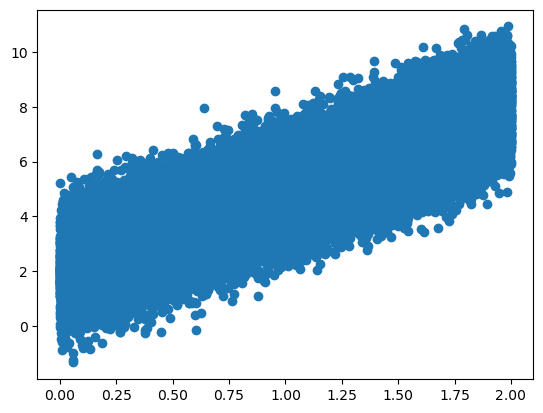

In [90]:
x, y = create_data(100000)

plt.scatter(x,y)

In [91]:
# f fonksiyonu (veriye bagli)

def f(b0, b1): # Ortalama KKT

  toplam = 0

  for i in range(len(x)):
    toplam += (y[i] - b0 - b1 * x[i]) ** 2   # y^_i = b0 + b1 x_i

  return toplam / len(x)

# f'nin gradyani. Veri sayısına bağlı olarak çok büyük sayılardan 
# kurtulmak için çıktıyı veri (satır) sayısına bölüyoruz

def grad_f(b0, b1):

    toplam1 = 0

    for i in range(len(x)):
        toplam1 += -2 * (y[i] - b0 - b1 * x[i])
    
    toplam2 = 0

    for i in range(len(x)):
        toplam2 += -2 * x[i] * (y[i] - b0 - b1 * x[i])
    
    return np.array([toplam1 / len(x), toplam2 / len(x)])


def norm(x):

  toplam = 0

  for i in range(len(x)):
    toplam += x[i] ** 2
  
  return np.sqrt(toplam)

In [100]:
%%time

f_degerleri = []

nokta = np.array([5, 5]) # nokta = (b0, b1) baslangic noktasi

f_degerleri.append(f(nokta[0], nokta[1]))

c = 0.1

hata = 10 ** -2

gradyan = grad_f(nokta[0], nokta[1])

sayac = 0

while norm(gradyan) > hata:

  nokta = nokta - c * gradyan

  f_degerleri.append(f(nokta[0], nokta[1]))

  gradyan = grad_f(nokta[0], nokta[1])

  sayac += 1

print( "Adım sayısı: ", sayac, "SONUÇ: Parametreler:", nokta,"Gradyanın son değeri: ", gradyan, "Fonksiyonun son değeri: ", f(nokta[0], nokta[1]))

Adım sayısı:  110 SONUÇ: Parametreler: [2.02678736 2.97626625] Gradyanın son değeri:  [ 0.00757673 -0.00641744] Fonksiyonun son değeri:  0.8115867571541827
CPU times: user 14.2 s, sys: 71.3 ms, total: 14.3 s
Wall time: 14.4 s


<function matplotlib.pyplot.show(close=None, block=None)>

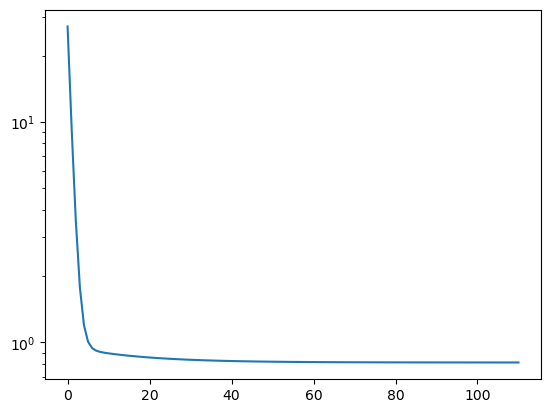

In [101]:
plt.plot(f_degerleri)
plt.yscale('log')
plt.show

In [102]:
%%time

import random

f_degerleri = []
sayac_degerleri = []

nokta = np.array([5, 5])


c = 0.01


# Rassal gradyan hesabi
i = random.randint(0, len(x) -1)
rassal_gradyan = np.array([-2 * (y[i] - nokta[0] - nokta[1] * x[i]), -2 * x[i] * (y[i] - nokta[0] - nokta[1] * x[i])]) 

    
sayac = 0

while True:
    
    nokta_eski = nokta.copy()

    nokta = nokta - c * rassal_gradyan
    
    if sayac % 10 == 0:
        f_value = f(nokta[0], nokta[1])
        print(sayac, nokta, norm(gradyan), rassal_gradyan, f_value) #, f(nokta[0], nokta[1]))
        f_degerleri.append(f_value)
        sayac_degerleri.append(sayac)

    # Rassal gradyan hesabi
    i = random.randint(0, len(x) -1)
    rassal_gradyan = np.array([-2 * (y[i] - nokta[0] - nokta[1] * x[i]), -2 * x[i] * (y[i] - nokta[0] - nokta[1] * x[i])])
   
    sayac += 1

    if sayac == 1000:
      break

print("Adım sayısı: ", sayac, "SONUÇ: Parametreler:", nokta,"Fonksiyonun son değeri: ", f(nokta[0], nokta[1]))

0 [4.88060289 4.85361678] 0.009929265667660005 [11.93971055 14.6383224 ] 24.37877285740153
10 [4.15382797 4.03916713] 0.009929265667660005 [6.23361369 5.94523706] 11.372623410506243
20 [3.64482885 3.24274659] 0.009929265667660005 [ 6.75086656 13.48698117] 4.397083253764945
30 [3.35257894 2.88704768] 0.009929265667660005 [2.09903911 1.3507444 ] 2.354017711364286
40 [3.21286159 2.74314013] 0.009929265667660005 [2.51014991 2.74461827] 1.7484146605844573
50 [3.00502745 2.52813594] 0.009929265667660005 [3.29682027 2.51345324] 1.1700495457457503
60 [2.98812548 2.56139961] 0.009929265667660005 [0.78023771 0.75997113] 1.1777314773064091
70 [2.90419667 2.46252837] 0.009929265667660005 [3.53488932 1.95234236] 1.0420033171429706
80 [2.88600286 2.48812171] 0.009929265667660005 [0.55518114 0.28334029] 1.0385722909576791
90 [2.77761256 2.47740582] 0.009929265667660005 [2.66834236 1.17749174] 0.9671235737676552
100 [2.62853414 2.35696031] 0.009929265667660005 [-0.43177211 -0.23256676] 0.9485156073958

<function matplotlib.pyplot.show(close=None, block=None)>

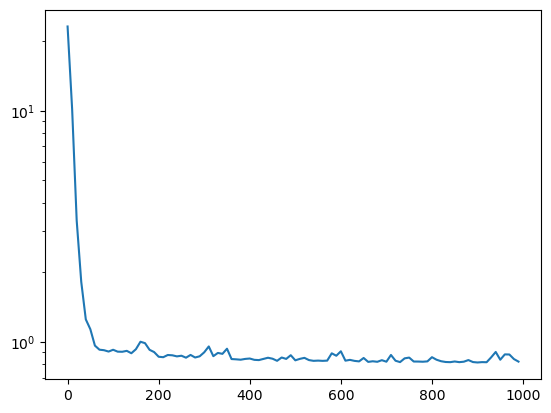

In [99]:
plt.plot(sayac_degerleri, f_degerleri)
plt.yscale('log')
plt.show

**Azalan Adım Boyu:**

In [119]:
%%time

import random

f_degerleri = []
sayac_degerleri = []

nokta = np.array([5, 5])


c = 0.1


# Rassal gradyan hesabi
i = random.randint(0, len(x) -1)
rassal_gradyan = np.array([-2 * (y[i] - nokta[0] - nokta[1] * x[i]), -2 * x[i] * (y[i] - nokta[0] - nokta[1] * x[i])]) 

    
sayac = 0

while True:
    
    nokta_eski = nokta.copy()

    nokta = nokta - (c / np.sqrt(sayac + 1)) * rassal_gradyan
    
    if sayac % 10 == 0:
        f_value = f(nokta[0], nokta[1])
        print(sayac, nokta, norm(gradyan), rassal_gradyan, f_value) #, f(nokta[0], nokta[1]))
        f_degerleri.append(f_value)
        sayac_degerleri.append(sayac)

    # Rassal gradyan hesabi
    i = random.randint(0, len(x) -1)
    rassal_gradyan = np.array([-2 * (y[i] - nokta[0] - nokta[1] * x[i]), -2 * x[i] * (y[i] - nokta[0] - nokta[1] * x[i])])
   
    sayac += 1

    if sayac == 200:
      break

print("Adım sayısı: ", sayac, "SONUÇ: Parametreler:", nokta,"Fonksiyonun son değeri: ", f(nokta[0], nokta[1]))

0 [4.49540883 4.90304165] 0.009929265667660005 [5.04591172 0.96958347] 21.37406847111194
10 [2.6504514  2.53844653] 0.009929265667660005 [1.43694189 0.28191323] 0.917708391958919
20 [2.57672569 2.5689988 ] 0.009929265667660005 [1.10222303 1.05686081] 0.8941388402463131
30 [2.45741528 2.49455057] 0.009929265667660005 [0.17047813 0.33626507] 0.8980393524274918
40 [2.56276323 2.65914214] 0.009929265667660005 [-1.8668092 -0.9421639] 0.8991920040025707
50 [2.59447514 2.75744943] 0.009929265667660005 [-3.25561878 -6.38922585] 0.9550230181481304
60 [2.58698971 2.77352662] 0.009929265667660005 [-0.08269237 -0.1288127 ] 0.9586668365694674
70 [2.62543102 2.83516181] 0.009929265667660005 [0.2032875  0.17602182] 1.0330442816038332
80 [2.56155097 2.82115775] 0.009929265667660005 [0.35926255 0.71072356] 0.9688292210239758
90 [2.47457725 2.80321816] 0.009929265667660005 [1.60254823 0.03903134] 0.9015921952420564
100 [2.40107423 2.74017032] 0.009929265667660005 [0.11447085 0.05244246] 0.85366287071572

<function matplotlib.pyplot.show(close=None, block=None)>

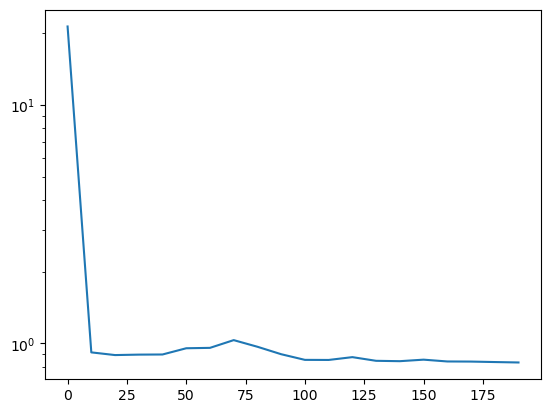

In [120]:
plt.plot(sayac_degerleri, f_degerleri)
plt.yscale('log')
plt.show